# Hierarchical Relational GNN
modified to 2 Protein-Patient edge types and train HRGNN to learn extreme attentions for the two edge-type

In [1]:
import pickle
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData

import pandas as pd
import networkx as nx
import argparse
import os
import sys
import math
from tqdm import tqdm

try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
sys.path.append(os.path.dirname(base_dir))

from hetero_base_models.utilities import convert_to_hetero_data
from hetero_base_models.train_hybridkg import (
    compute_link_loss, 
    split_edges,
    evaluate_link,
    build_x_dict,
    set_seed
)
from SHGP.HRGNN_models import get_model
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
config = {
'graph_path': "../datasets/Patient_KGs/G_adni_dual_hybrid_ecdf.pkl",
'output_dir': "../results/HRGNN",
'model':'gat',
'hidden_channels': 128,
'out_channels': 2,
'att_channels':32,
'num_layers': 3,
'heads': 4,
'dropout': 0.3,
'epochs': 100,
'lr': 5e-3,
'weight_decay': 1e-5,
'lambda_link': 0.2,
'val_ratio': 0.15,
'test_ratio':0.15,
'seed':42,
'device': 'cuda',
'assign_method':'cls',
}
# convert config to Namespace
args = argparse.Namespace(**config)

In [2]:
def merge_patient_protein_edges(data):
    """Rebuild HeteroData() with merged Patient-Proetin edges."""
    new_data = HeteroData()
    
    # Copy node features
    for node_type in data.node_types:
        for key, value in data[node_type].items():
            new_data[node_type][key] = value

    # Collect edges
    d_edges = []
    rev_d_edges = []

    h_edges = []
    rev_h_edges = []

    # Keep unrelated edge types
    for et in data.edge_types:
        src, rel, dst = et
        edge_index = data[et].edge_index

        # Patient <-> Protein relations
        if (src == 'Patient' and dst == 'Protein') or (src == 'Protein' and dst == 'Patient'):

            # reverse edges
            if 'rev' in rel:
                if 'disease' in rel:
                    rev_d_edges.append(edge_index)
                else:
                    rev_h_edges.append(edge_index)
            # forward edges
            else:
                if 'disease' in rel:
                    d_edges.append(edge_index)
                else:
                    h_edges.append(edge_index)

        # keep other edge types
        else:
            new_data[et].edge_index = edge_index

    # Merge disease relations
    new_data[('Patient', 'reg_disease', 'Protein')].edge_index = torch.cat(d_edges,dim=1,)
    # Merge healthy relations
    new_data[('Patient', 'reg_control', 'Protein')].edge_index = torch.cat(h_edges,dim=1,)
    # Reverse disease
    new_data[('Protein', 'rev_reg_disease', 'Patient')].edge_index = torch.cat(rev_d_edges,dim=1,)
    # Reverse healthy
    new_data[('Protein', 'rev_reg_control', 'Patient')].edge_index = torch.cat(rev_h_edges,dim=1,)

    return new_data

In [5]:
# Setup
set_seed(args.seed)
device = torch.device(args.device if torch.cuda.is_available() else "cpu")

# 1. Prepare HeteroData
with open(args.graph_path, "rb") as f:
    G = pickle.load(f)
data, node_mappings = convert_to_hetero_data(G)
new_data = merge_patient_protein_edges(data)

# Build features
new_data.x_dict = build_x_dict(new_data)
new_data.edge_index_dict = {et:new_data[et].edge_index for et in new_data.edge_types}

# Labels
y = new_data["Patient"].y
num_classes = int(y.max().item() + 1) if y.dim() == 1 else y.size(-1)
print(f"Number of classes: {num_classes}")


Starting conversion from NetworkX to HeteroData...


/Users/yuxiaoxuan/master_thesis/HybridKG/hetero_base_models/utilities.py:40: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1719361045918/work/torch/csrc/utils/tensor_new.cpp:277.)
  patient_x = torch.tensor([G.nodes[pid]['x'] for pid in p_ids], dtype=torch.float)


HeteroData created: 25 node types, 820 edge types.
Number of classes: 2


In [6]:
for et in new_data.edge_types:
    if 'Patient' in et:
        print(et)

('Patient', 'similar', 'Patient')
('Patient', 'reg_disease', 'Protein')
('Patient', 'reg_control', 'Protein')
('Protein', 'rev_reg_disease', 'Patient')
('Protein', 'rev_reg_control', 'Patient')


In [11]:
def hierarchical_attention_loss(
    attentions:list,
    y,
    mask,
    disease_index,
    control_index,
):
    """
    Soft supervision over semantic relation attention.

    Args:
    
    attentions:list: List of attention dictionaries from all layers.Example:
                attentions[layer]["Patient"]
    y:Tensor:Binary labels, shape: [N]
    disease_index: Index of disease relation attention.
    control_index: Index of control relation attention.

    Returns:
        Average attention supervision loss across all layers.
    """
    y = y[mask]
    total_att_loss = 0.0
    # supervise ALL layers
    for layer_att in attentions:
        # semantic attention tensor: shape:[N, num_relations]
        try:
            beta = layer_att['Patient'][mask]
        except:
            beta=layer_att['Patient']['attention'][mask]
        
        # disease/control attentions
        disease_att = beta[:, disease_index]
        control_att = beta[:, control_index]

        # relative preference logit
        # positive: disease > control
        # negative: control > disease
        att_logit = disease_att - control_att

        # BCE supervision
        att_loss = F.binary_cross_entropy_with_logits(
            att_logit, y.float(),)

        total_att_loss += att_loss

    # average across layers
    total_att_loss = total_att_loss / len(attentions)

    return total_att_loss

In [8]:
def train(model, data, lambda_att=0.1):
    model.train()
    optimizer.zero_grad()

    out, attention_weights = model(data.x_dict, data.edge_index_dict)
    mask = data['Patient'].train_mask

    # cls loss
    cls_loss = F.cross_entropy(out['Patient'][mask], data['Patient'].y[mask])

    # attention loss
    rel_names = attention_weights[-1]["Patient"]["relation_names"]
    disease_idx = rel_names.index("Protein__rev_reg_disease__Patient")
    control_idx = rel_names.index("Protein__rev_reg_control__Patient")
    att_loss = hierarchical_attention_loss(attentions=attention_weights,
                                           y=data['Patient'].y,
                                           mask=mask,
                                           disease_index=disease_idx,
                                           control_index=control_idx,
                                           )
    loss = cls_loss + lambda_att*att_loss

    loss.backward()
    optimizer.step()

    return float(loss), float(cls_loss), float(att_loss), attention_weights

@torch.no_grad()
def test(model, data):
    model.eval()
    out, attention_weights = model(data.x_dict, data.edge_index_dict)
    pred = out['Patient'].argmax(dim=-1)
    probs = torch.softmax(out['Patient'], dim=-1,)[:,1]

    # move to cpu
    y_true = data['Patient'].y.cpu().numpy()
    pred = pred.detach().cpu().numpy()
    prob = probs.detach().cpu().numpy()

    #metrics
    accs = []
    f1s = []
    aurocs = []
    auprcs = []
    for split in ['train_mask', 'val_mask', 'test_mask']:
        mask = data['Patient'][split]
        acc = (pred[mask] == y_true[mask]).sum() / mask.sum()
        accs.append(float(acc))
        # f1
        f1 = f1_score(y_true[mask], pred[mask],)
        f1s.append(f1)
        auroc = roc_auc_score(y_true[mask],prob[mask],)
        aurocs.append(auroc)
        auprc = average_precision_score(y_true[mask],prob[mask],)
        auprcs.append(auprc)
    
    metrics = pd.DataFrame({'Accuracy':accs, 'F1_score':f1s, 'AUROC':aurocs, 'AUPRC':auprcs})

    return accs, attention_weights, metrics

In [9]:
# 3. model is built
encoder, model = get_model(data=new_data,
                   model_type = args.model,
                   hidden_channels=args.hidden_channels, 
                   out_channels=2, 
                   att_channels=args.att_channels,
                   num_layers=args.num_layers, 
                   dropout=args.dropout,
                   num_classes=2,
                   device=device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=args.lr,
    weight_decay=args.weight_decay
    )

# train
for epoch in range(1, 2):
    total_loss, cls_loss, att_loss, train_att = train(model=encoder, data=new_data)
    test_accs, test_att, metrics = test(model=encoder, data=new_data)

    train_acc, val_acc, test_acc = test_accs
    print(f'Epoch: {epoch:03d}, Total_loss: {total_loss:.4f}, Cls_loss:{cls_loss}, Attention_loss:{att_loss},\nTrain: {train_acc:.4f}, '
          f'Val: {val_acc:.4f}, Test: {test_acc:.4f}')

Epoch: 001, Total_loss: 0.7774, Cls_loss:0.708137035369873, Attention_loss:0.6928368210792542,
Train: 0.5346, Val: 0.5294, Test: 0.5362


In [28]:
metrics

,Accuracy,F1_score,AUROC,AUPRC
0,0.767296,0.800000,0.884420,0.905293
1,0.529412,0.578947,0.526042,0.583158
2,0.492754,0.578313,0.472128,0.531007


In [10]:
for layer in range(len(train_att)):
    print(train_att[layer]['Patient'])

{'relation_names': ['self', 'Patient__similar__Patient', 'Protein__rev_reg_disease__Patient', 'Protein__rev_reg_control__Patient'], 'attention': tensor([[0.2486, 0.2515, 0.2499, 0.2499],
        [0.2500, 0.2456, 0.2528, 0.2515],
        [0.2471, 0.2476, 0.2509, 0.2544],
        ...,
        [0.2505, 0.2478, 0.2475, 0.2543],
        [0.2464, 0.2395, 0.2601, 0.2540],
        [0.2527, 0.2530, 0.2474, 0.2470]], grad_fn=<SoftmaxBackward0>)}
{'relation_names': ['self', 'Patient__similar__Patient', 'Protein__rev_reg_disease__Patient', 'Protein__rev_reg_control__Patient'], 'attention': tensor([[0.2522, 0.2478, 0.2525, 0.2475],
        [0.2380, 0.2504, 0.2479, 0.2637],
        [0.2483, 0.2508, 0.2526, 0.2483],
        ...,
        [0.2411, 0.2635, 0.2513, 0.2442],
        [0.2547, 0.2498, 0.2458, 0.2497],
        [0.2489, 0.2692, 0.2392, 0.2427]], grad_fn=<SoftmaxBackward0>)}
{'relation_names': ['self', 'Patient__similar__Patient', 'Protein__rev_reg_disease__Patient', 'Protein__rev_reg_control_

In [ ]:
dst_relations = {}
for rel in new_data.edge_types:
    src, edge, dst = rel
    if dst not in dst_relations:
        dst_relations[dst] = []
    dst_relations[dst].append(rel)

dst_relations['Patient']

[('Protein', 'rev_reg_disease', 'Patient'),
 ('Protein', 'rev_reg_control', 'Patient')]

In [12]:
import json

def extract_metrics(root_dir):
    """
    Walks through the directory structure:
    root_dir / dataset / scoring / model / method/ metrics.json
    """
    data_list = []
    
    # We expect the root_dir to contain ['ADKG', 'HealthyKG', 'merge', 'hybrid']
    for dataset in os.listdir(root_dir):
        pm_path = os.path.join(root_dir, dataset)
        if not os.path.isdir(pm_path): continue
        
        for scoring in os.listdir(pm_path):
            ds_path = os.path.join(pm_path, scoring)
            if not os.path.isdir(ds_path): continue
            
            for model_type in os.listdir(ds_path):
                sc_path = os.path.join(ds_path, model_type)
                if not os.path.isdir(sc_path): continue
                
                for processed_method in os.listdir(sc_path):
                    m_path = os.path.join(sc_path, processed_method)
                    metrics_file = os.path.join(m_path, 'test_metrics.json')
                    
                    if os.path.exists(metrics_file):
                        with open(metrics_file, 'r') as f:
                            metrics = json.load(f)
                        
                        
                        data_list.append({
                            "Method": processed_method,
                            "Dataset": dataset,
                            "Scoring": scoring,
                            "Model": model_type,
                            "Accuracy": metrics.get("Accuracy"),
                            "F1": metrics.get("F1_score"),
                            "AUROC": metrics.get("AUROC"),
                            "AUPRC": metrics.get("AUPRC")
                        })
    
    return pd.DataFrame(data_list)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_grouped_performance(df, metric_name="AUROC"):
    """
    Groups by Method on the X-axis.
    Each group contains bars for different Dataset + Scoring combinations.
    """
    # 1. Create a combined column for the legend/bars
    # This turns 'adni' and 'ecdf' into 'adni - ecdf'
    df['Condition'] = df['Dataset'] + " (" + df['Scoring'] + ")"
    
    plt.figure(figsize=(12, 7))
    sns.set_style("whitegrid")
    
    # 2. Plot
    # x="Method": Groups are ADKG, HealthyKG, merge, etc.
    # hue="Condition": Individual bars for adni(ecdf), geo(ecdf), etc.
    ax = sns.barplot(
        data=df, 
        x="Method", 
        y=metric_name, 
        hue="Condition", 
        palette="muted",
        edgecolor="black"
    )
    
    # 3. Formatting
    plt.title(f"Performance Comparison by Network Construction Method and Dataset ({metric_name})", fontsize=16, pad=20)
    plt.ylabel(metric_name, fontsize=12)
    plt.xlabel("Network Construction Method", fontsize=12)
    
    # Fix legend position so it doesn't cover bars
    plt.legend(title="Dataset (Scoring)", bbox_to_anchor=(1.02, 1), loc='upper left')
    
    # Optional: Add value labels on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)

    plt.tight_layout()
    plt.show()

def plot_metrics(df_melted):
   
    plt.figure(figsize=(16,20))
    sns.set_theme(style="whitegrid")

    g = sns.catplot(
        data=df_melted, 
        kind="bar",
        x="Dataset", 
        y="Score", 
        hue="Method",
        col="Metric", 
        col_wrap=2,
        palette="muted", 
        height=4, 
        aspect=1.2
    )

    g.set_axis_labels("Dataset", "Score Value")
    g.set_titles("{col_name}")

    # --- ADD LABELS HERE ---
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    # -----------------------

    sns.move_legend(
        g, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
    )

    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300)
    plt.show()

In [14]:
results_df = extract_metrics('../results/HRGNN')
results_df
df_melted = results_df.melt(
        id_vars=['Dataset', 'Scoring', 'Model', 'Method'], 
        value_vars=['Accuracy', 'F1', 'AUROC', 'AUPRC'],
        var_name='Metric', 
        value_name='Score'
    )
df_melted

,Dataset,Scoring,Model,Method,Metric,Score
0,geo,ecdf,gat,dual_hybrid,Accuracy,0.661972
1,geo,ecdf,gat,merge,Accuracy,0.943662
2,geo,ecdf,gcn,dual_hybrid,Accuracy,0.661972
3,geo,ecdf,gcn,merge,Accuracy,0.915493
4,adni,ecdf,gat,dual_hybrid,Accuracy,0.536232
5,adni,ecdf,gat,merge,Accuracy,0.550725
6,adni,ecdf,gcn,dual_hybrid,Accuracy,0.579710
7,adni,ecdf,gcn,merge,Accuracy,0.579710
8,geo,ecdf,gat,dual_hybrid,F1,0.796610
9,geo,ecdf,gat,merge,F1,0.958333


<Figure size 1600x2000 with 0 Axes>

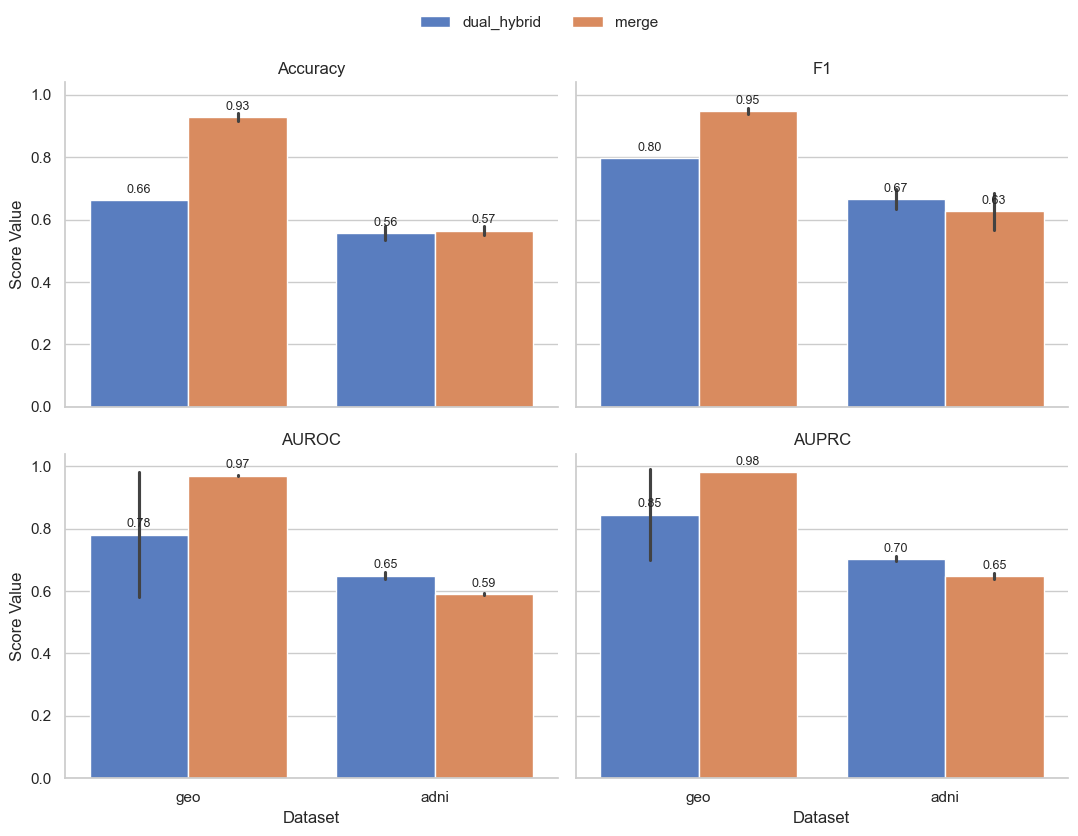

In [15]:
plot_metrics(df_melted)

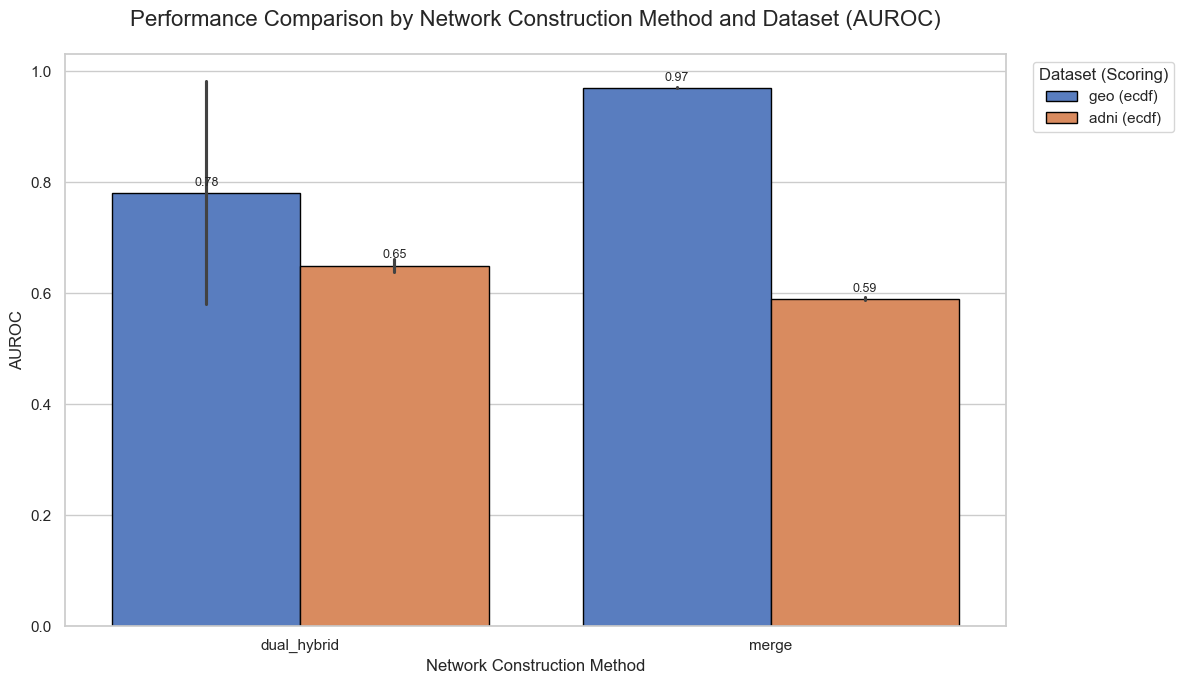

In [16]:
plot_grouped_performance(results_df)

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_metrics(df_melted):
    # 1. Create a combined column for the Hue
    df_plot = df_melted.copy()
    df_plot['Model_Method'] = df_plot['Model'] + " (" + df_plot['Method'] + ")"

    sns.set_theme(style="whitegrid")

    # 2. Use the combined column as 'hue'
    g = sns.catplot(
        data=df_plot, 
        kind="bar",
        x="Dataset", 
        y="Score", 
        hue="Model_Method", 
        col="Metric", 
        col_wrap=2,
        palette="viridis", 
        height=5, 
        aspect=1.3,
        sharey=False 
    )

    g.set_axis_labels("Dataset", "Score Value")
    g.set_titles("{col_name}")

    # Add bar labels for precision
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8)
        ax.set_ylim(0, df_plot['Score'].max() * 1.15)

    # --- UPDATES START HERE ---

    # 1. Move Legend to the Bottom
    # We use "lower center" and adjust bbox_to_anchor to sit below the plots
    sns.move_legend(
        g, "lower center",
        bbox_to_anchor=(.5, -0.05), # Move below the x-axis (y < 0)
        ncol=1,                     # Increased columns to fit horizontally
        title="Model & Method Configuration", 
        frameon=True,
    )

    # 2. Add a Figure Title
    # g.fig refers to the underlying Matplotlib figure
    g.fig.suptitle("Model Performance Comparison Across Datasets", fontsize=16, fontweight='bold')

    # 3. Adjust layout to make room for the title (top) and legend (bottom)
    # plt.tight_layout() often fights with suptitle, so we use subplots_adjust
    g.fig.subplots_adjust(top=0.9, bottom=0.15) 

    # --- UPDATES END HERE ---

    plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

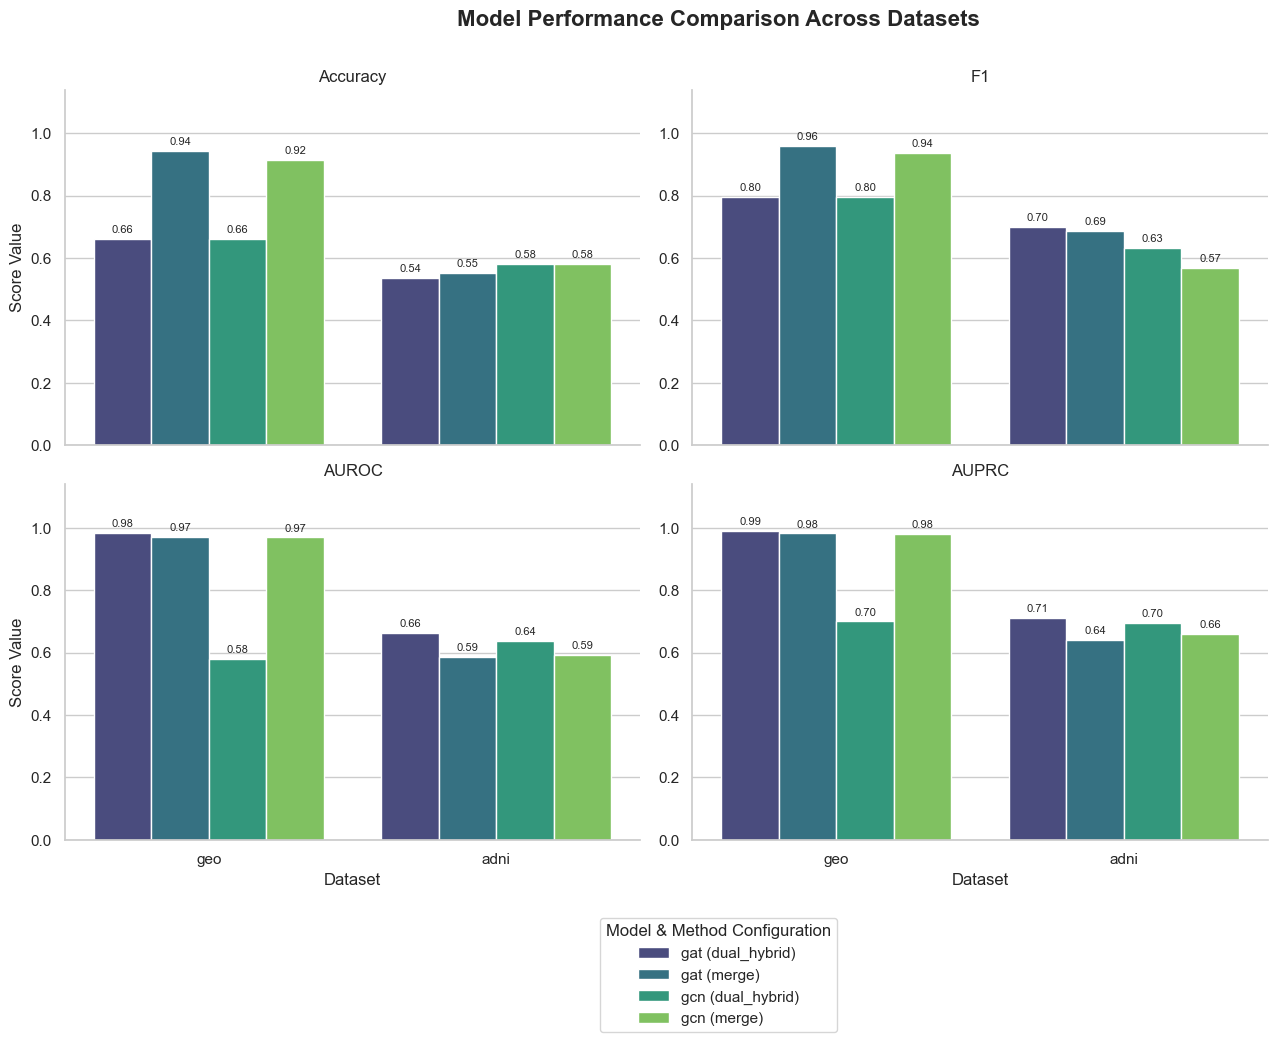

In [24]:
plot_metrics(df_melted)